In [7]:
import numpy as np
import bayesflow as bf
import sys
sys.path.append("../")
from src.generative_models import *
from src.priors import *

In [8]:
NUM_VAL_SIM = 1000
NUM_SAMPLES = 2000

In [9]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=3,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

## PT Model

In [10]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/{pt_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/pt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/pt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [11]:
val_data = pt_model(NUM_VAL_SIM)
test_data = pt_configurator(val_data)
true_params = val_data['prior_draws']

In [12]:
post_samples_z = pt_amortizer.sample(test_data, NUM_SAMPLES)

In [13]:
post_samples = post_samples_z * PT_PRIOR_STD + PT_PRIOR_MEAN

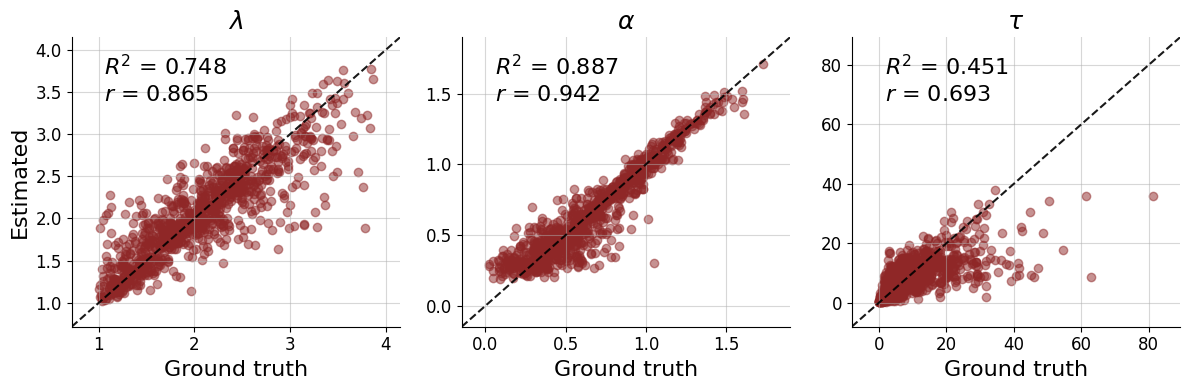

In [14]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=pt_param_names,
    uncertainty_agg=None
)

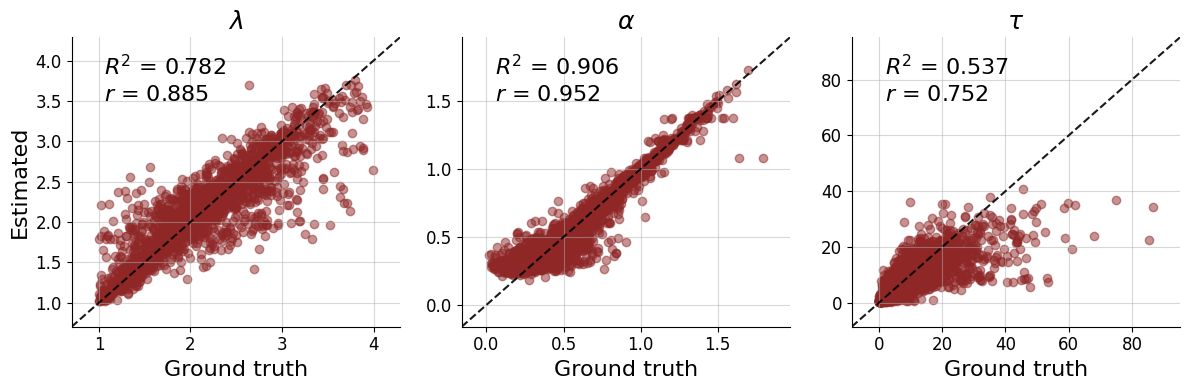

In [8]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=pt_param_names,
    uncertainty_agg=None
)

## MVL Model

In [17]:
mvl_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

mvl_trainer = bf.trainers.Trainer(
    generative_model=mvl_model, 
    amortizer=mvl_amortizer, 
    configurator=mvl_configurator, 
    checkpoint_path=f"../checkpoints/{mvl_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/mvl_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/mvl_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [18]:
val_data = mvl_model(NUM_VAL_SIM)
test_data = mvl_configurator(val_data)
true_params = val_data['prior_draws']

In [19]:
post_samples_z = mvl_amortizer.sample(test_data, NUM_SAMPLES)

In [20]:
post_samples = post_samples_z * MVL_PRIOR_STD + MVL_PRIOR_MEAN

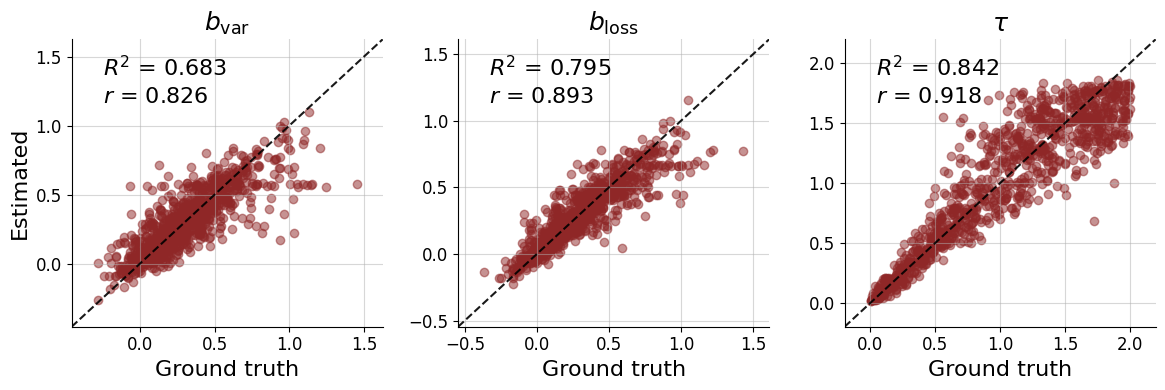

In [21]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=mvl_param_names,
    uncertainty_agg=None
)

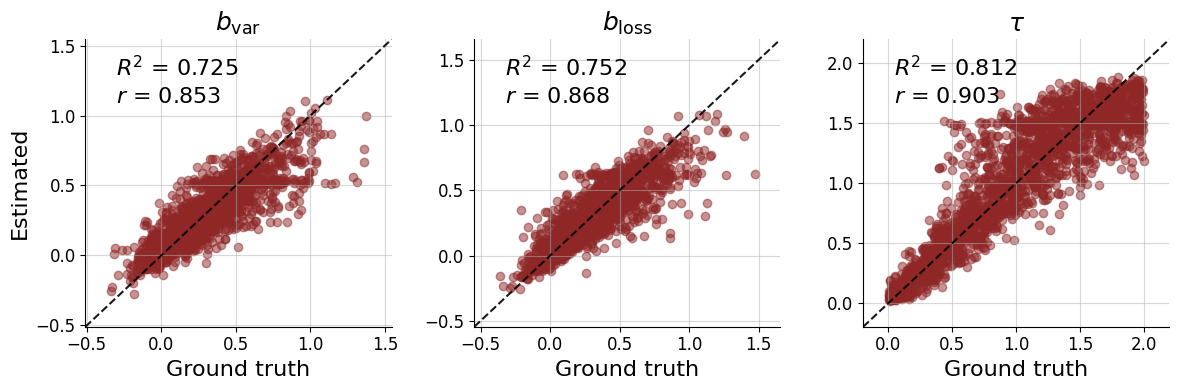

In [13]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=mvl_param_names,
    uncertainty_agg=None
)